In [1]:
import os
os.chdir('/mnt/d/KU_year3/Statistics/stat_csv')
os.getcwd()

'/mnt/d/KU_year3/Statistics/stat_csv'

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
%matplotlib inline

In [3]:
# df = pd.read_csv("titanic_data.csv")
# df = pd.read_csv("bike_hour.csv")
df = pd.read_csv("adult-u8.csv")
# df = pd.read_csv("bkk_listings.csv")
# See data examples in the first 10 rows
df.head(10)

,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [4]:
# See data examples in the last 5 rows
df.tail()

,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


## Check data size and data types

In [5]:
df.shape

(32561, 15)

In [6]:
df.columns

Index(['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num',
       'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
       'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country', 'Target'],
      dtype='object')

In [7]:
df.dtypes

Age                int64
Workclass         object
fnlwgt             int64
Education         object
Education_Num      int64
Martial_Status    object
Occupation        object
Relationship      object
Race              object
Sex               object
Capital_Gain       int64
Capital_Loss       int64
Hours_per_week     int64
Country           object
Target            object
dtype: object

In [8]:
[col for col in df.columns if '?' in df[col].unique()]

['Workclass', 'Occupation', 'Country']

## Handle missing data

<Axes: >

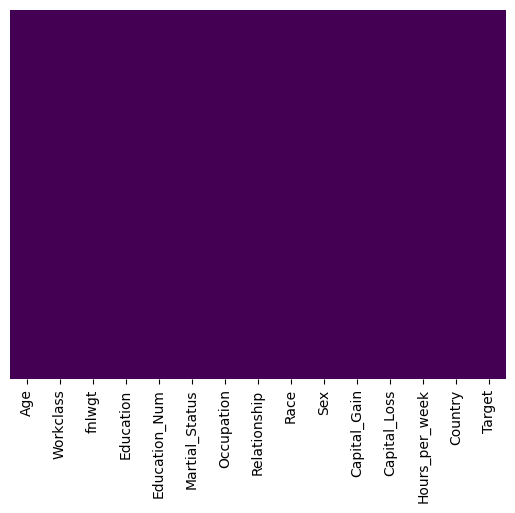

In [9]:
# Plot heatmap to visualize locations of missing values
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [10]:
# count missing values in each variable
df.isnull().sum()

Age               0
Workclass         0
fnlwgt            0
Education         0
Education_Num     0
Martial_Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_Gain      0
Capital_Loss      0
Hours_per_week    0
Country           0
Target            0
dtype: int64

In [11]:
# find missing value percent for each variable
null_percent = df.isnull().sum()/len(df)*100
null_percent

Age               0.0
Workclass         0.0
fnlwgt            0.0
Education         0.0
Education_Num     0.0
Martial_Status    0.0
Occupation        0.0
Relationship      0.0
Race              0.0
Sex               0.0
Capital_Gain      0.0
Capital_Loss      0.0
Hours_per_week    0.0
Country           0.0
Target            0.0
dtype: float64

In [12]:
new_df = df.copy()  
# Leave df to be the original dataframe in case of any value check for later

In [13]:
new_df = new_df.replace('?', np.nan)

<Axes: >

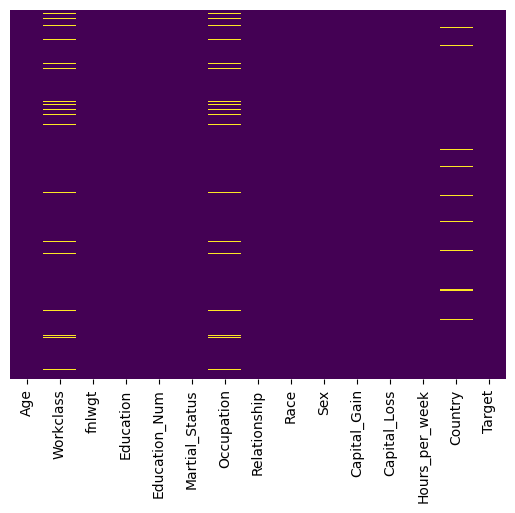

In [14]:
sns.heatmap(new_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [15]:
new_df.isnull().sum()

Age                  0
Workclass         1836
fnlwgt               0
Education            0
Education_Num        0
Martial_Status       0
Occupation        1843
Relationship         0
Race                 0
Sex                  0
Capital_Gain         0
Capital_Loss         0
Hours_per_week       0
Country            583
Target               0
dtype: int64

In [16]:
null_percent = new_df.isnull().sum()/len(df)*100
null_percent

Age               0.000000
Workclass         5.638647
fnlwgt            0.000000
Education         0.000000
Education_Num     0.000000
Martial_Status    0.000000
Occupation        5.660146
Relationship      0.000000
Race              0.000000
Sex               0.000000
Capital_Gain      0.000000
Capital_Loss      0.000000
Hours_per_week    0.000000
Country           1.790486
Target            0.000000
dtype: float64

In [17]:
# Handle missing values in select_var column, "Workclass"
select_var = 'Workclass'
new_df[select_var].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', nan, 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

<Axes: >

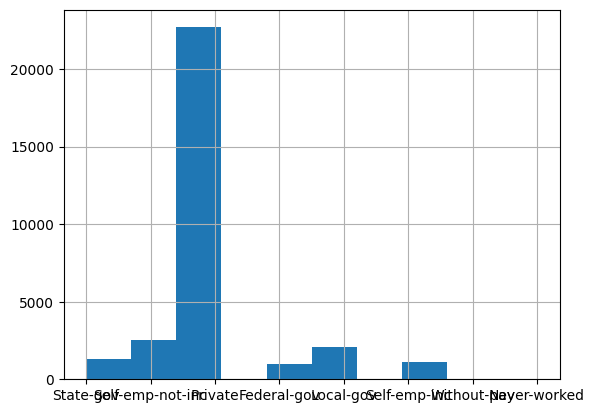

In [18]:
new_df[select_var].hist()

In [19]:
new_df[select_var].mode()[0]

'Private'

In [20]:
new_df[select_var].value_counts()['Private']

np.int64(22696)

In [21]:
new_df[select_var].fillna(df[select_var].mode()[0], inplace=True)

/tmp/ipykernel_1793/587774482.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df[select_var].fillna(df[select_var].mode()[0], inplace=True)


In [22]:
select_var = 'Occupation'
new_df[select_var].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', nan, 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

<Axes: >

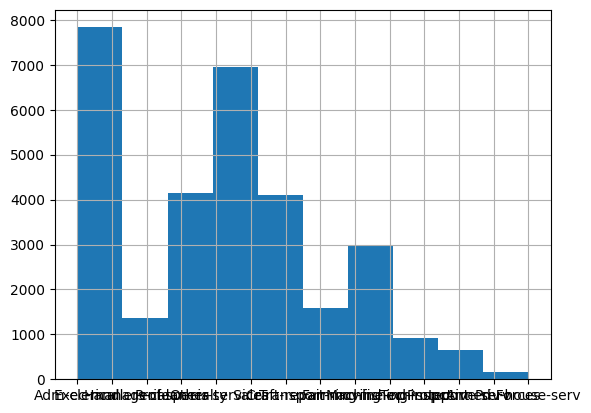

In [23]:
new_df[select_var].hist()

In [24]:
new_df.dropna(subset=['Occupation'], inplace=True)

<Axes: >

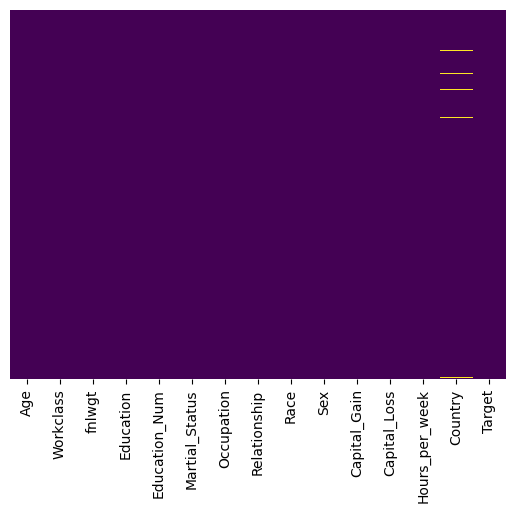

In [25]:
sns.heatmap(new_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [26]:
select_var = 'Country'
new_df[select_var].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', nan, 'Mexico',
       'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany', 'Iran',
       'Philippines', 'Poland', 'Columbia', 'Cambodia', 'Thailand',
       'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'Italy', 'China', 'South', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [27]:
new_df[select_var].value_counts()

Country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
El-Salvador                     100
India                           100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Columbia                         56
Poland                           56
Haiti                            42
Iran                             42
Taiwan                           42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece                           29
France              

<Axes: >

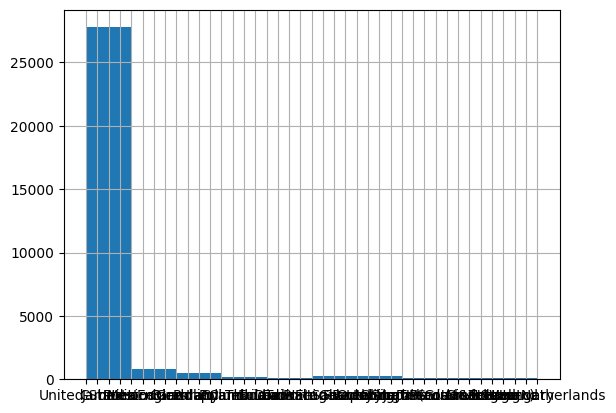

In [28]:
new_df[select_var].hist()

In [29]:
new_df[select_var].fillna(new_df[select_var].mode()[0], inplace=True) 

/tmp/ipykernel_1793/4026118916.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df[select_var].fillna(new_df[select_var].mode()[0], inplace=True)


<Axes: >

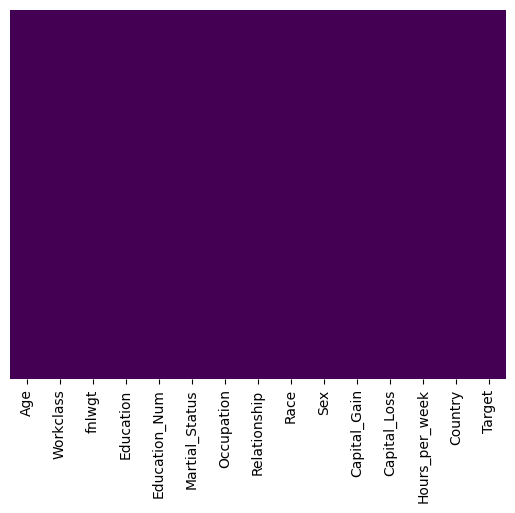

In [30]:
sns.heatmap(new_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [31]:
# Check out updated size 
new_df.shape

(30718, 15)

In [32]:
# After replacing and removing missing values, re-check %missing data
new_df.isnull().sum()/len(new_df)*100

Age               0.0
Workclass         0.0
fnlwgt            0.0
Education         0.0
Education_Num     0.0
Martial_Status    0.0
Occupation        0.0
Relationship      0.0
Race              0.0
Sex               0.0
Capital_Gain      0.0
Capital_Loss      0.0
Hours_per_week    0.0
Country           0.0
Target            0.0
dtype: float64

## Data Distributions / Histograms

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'fnlwgt'}>],
       [<Axes: title={'center': 'Education_Num'}>,
        <Axes: title={'center': 'Capital_Gain'}>],
       [<Axes: title={'center': 'Capital_Loss'}>,
        <Axes: title={'center': 'Hours_per_week'}>]], dtype=object)

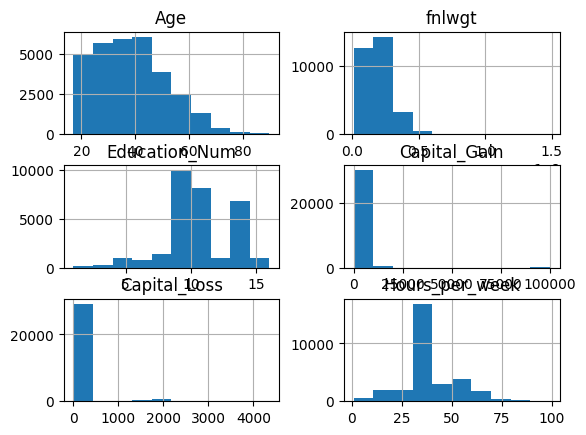

In [33]:
# Plot histograms for numerical variables
new_df.hist()

Text(0, 0.5, 'Frequency')

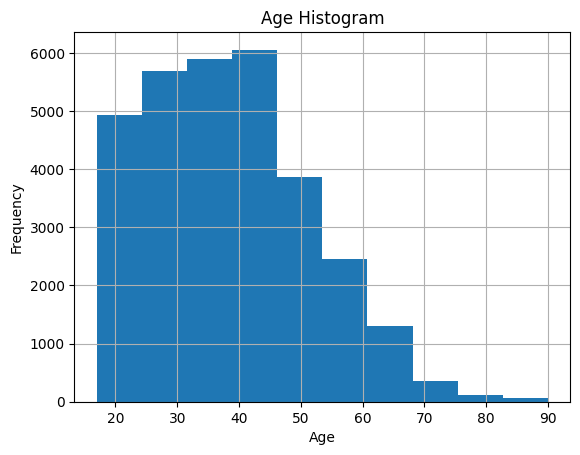

In [34]:
selected_var = 'Age'

# All 3 lines below construct "frequency" histogram for Age
new_df[selected_var].hist()
#new_df.hist(column=selected_var)
#new_df.Age.hist()

plt.title(selected_var + ' Histogram')
plt.xlabel(selected_var)
plt.ylabel('Frequency')
# See more options of histogram at https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html

Text(0, 0.5, 'Probability')

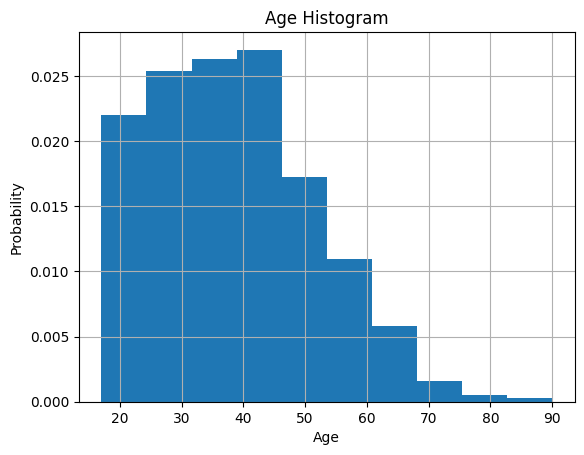

In [35]:
# Construct "probability" histogram for Age
new_df.hist(column=selected_var, density=True)
plt.title(selected_var + ' Histogram')
plt.xlabel(selected_var)
plt.ylabel('Probability')

In [36]:
new_df.columns

Index(['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num',
       'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
       'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country', 'Target'],
      dtype='object')

In [37]:
# Compute skewness of variables
num_columns = ['Age', 'fnlwgt', 'Education_Num', 'Capital_Gain', 'Capital_Loss', 'Hours_per_week']
num_df = new_df[num_columns]
num_df.skew()

Age                0.531696
fnlwgt             1.457210
Education_Num     -0.310354
Capital_Gain      11.785882
Capital_Loss       4.514329
Hours_per_week     0.331819
dtype: float64

In [38]:
# Compute kurtosis of variables
num_columns = ['Age', 'fnlwgt', 'Education_Num', 'Capital_Gain', 'Capital_Loss', 'Hours_per_week']
num_df = new_df[num_columns]
num_df.kurt()

Age                -0.137092
fnlwgt              6.361585
Education_Num       0.631231
Capital_Gain      150.279333
Capital_Loss       19.401249
Hours_per_week      3.164905
dtype: float64

## Normality Check

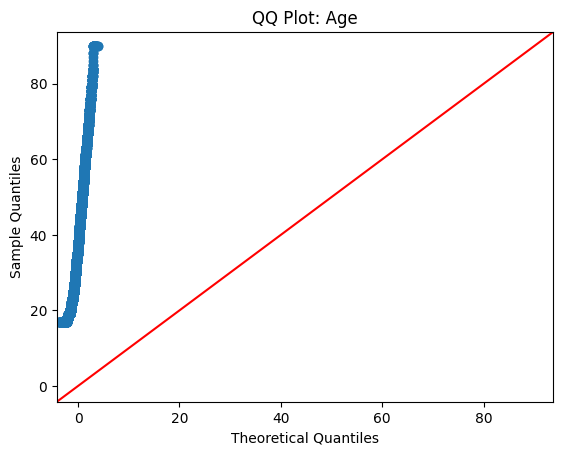

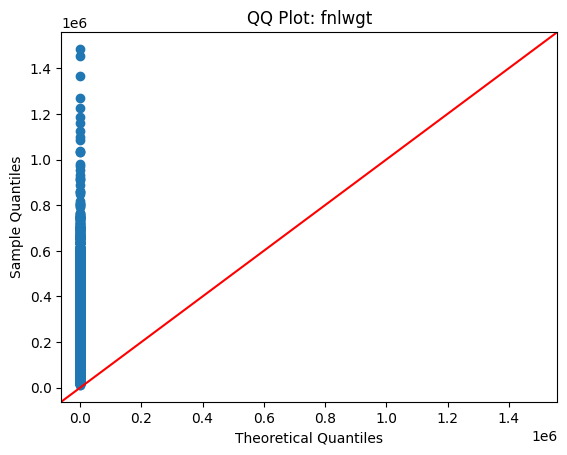

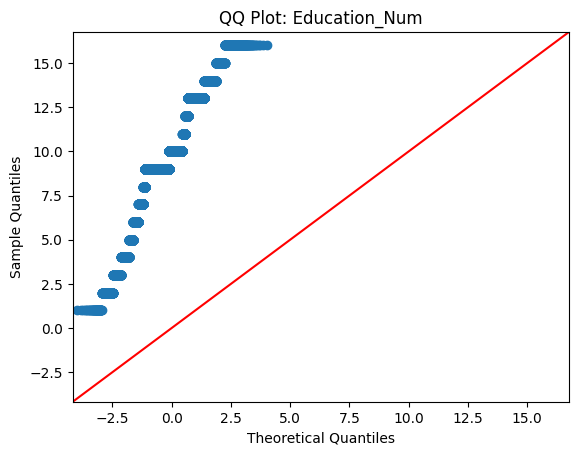

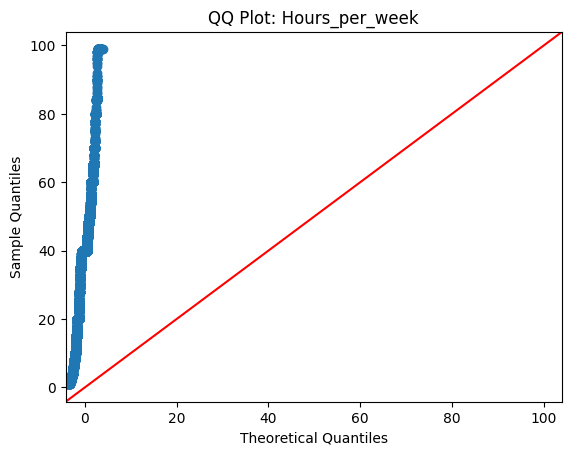

In [39]:
suspect = ['Age', 'fnlwgt', 'Education_Num', 'Hours_per_week']
for selected_var in suspect:
    sm.qqplot(df[selected_var], line='45')
    plt.title("QQ Plot: " + selected_var)
    plt.show()

In [40]:
from scipy.stats import normaltest

for selected_var in suspect:
    stat, p = normaltest(df[selected_var])
    print(f"{selected_var} -> p-value:", p)
    
    if p > 0.05:
        print("Fail to reject H0 → Data looks normal")
    else:
        print("Reject H0 → Data is NOT normal")

Age -> p-value: 0.0
Reject H0 → Data is NOT normal
fnlwgt -> p-value: 0.0
Reject H0 → Data is NOT normal
Education_Num -> p-value: 3.5897196971962224e-178
Reject H0 → Data is NOT normal
Hours_per_week -> p-value: 0.0
Reject H0 → Data is NOT normal


## Boxplots

In [41]:
# List names of variables 
new_df.columns

Index(['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num',
       'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
       'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country', 'Target'],
      dtype='object')

<Axes: xlabel='Age'>

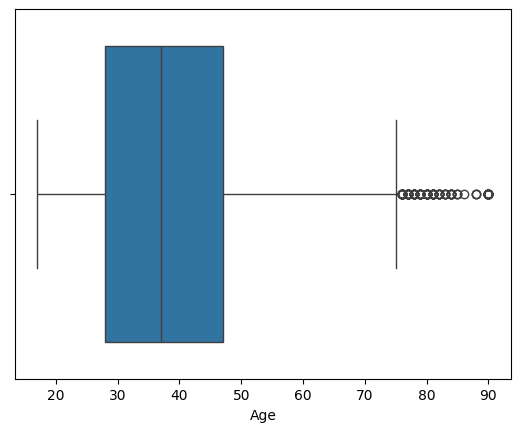

In [42]:
# Plot boxplot of selected_var variable with default threshold for outliers, Q1-1.5IQR, Q3+1.5IQR
selected_var = 'Age'
sns.boxplot(x=selected_var, data=new_df)

<Axes: xlabel='Age'>

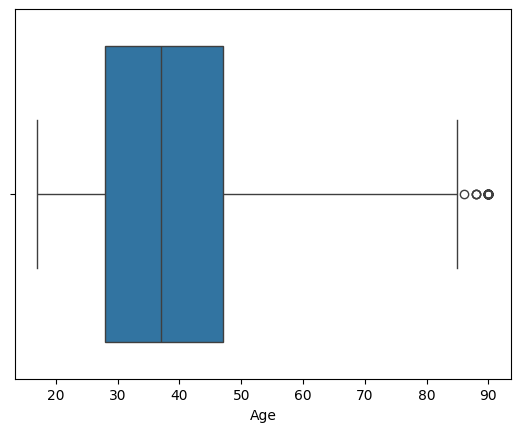

In [43]:
# Plot boxplot of selected_var variable with adjusted threshold for outliers, Q1-2.0IQR, Q3+2.0IQR
selected_var = 'Age'
sns.boxplot(x=selected_var, data=new_df, whis=2.0)

<Axes: xlabel='Age'>

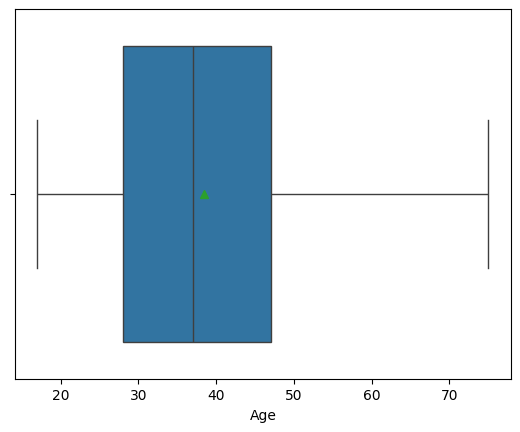

In [44]:
# Plot boxplot of selected_var variable without outliers and show mean
selected_var = 'Age'
sns.boxplot(x=selected_var, data=new_df, showmeans=True, showfliers=None)
# See more options for boxplot at https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html

In [45]:
def scan_outliers(df, method="both"):
    """
    Generates from ChatGPT
    """
    outlier_report = {}

    for col in df.select_dtypes(include=[np.number]).columns:
        series = df[col]

        col_result = {}

        # --- IQR Method ---
        if method in ["iqr", "both"]:
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1

            lower_iqr = Q1 - 1.5 * IQR
            upper_iqr = Q3 + 1.5 * IQR

            outliers_iqr = series[(series < lower_iqr) | (series > upper_iqr)]
            col_result["iqr"] = not outliers_iqr.empty

        # --- Standard Deviation Method ---
        if method in ["sd", "both"]:
            mean = series.mean()
            std = series.std()

            lower_sd = mean - 3 * std
            upper_sd = mean + 3 * std

            outliers_sd = series[(series < lower_sd) | (series > upper_sd)]
            col_result["sd"] = not outliers_sd.empty

        outlier_report[col] = col_result

    return outlier_report

In [46]:
scan_outliers(new_df, method="both")

{'Age': {'iqr': True, 'sd': True},
 'fnlwgt': {'iqr': True, 'sd': True},
 'Education_Num': {'iqr': True, 'sd': True},
 'Capital_Gain': {'iqr': True, 'sd': True},
 'Capital_Loss': {'iqr': True, 'sd': True},
 'Hours_per_week': {'iqr': True, 'sd': True}}

## Descriptive Statistics : Centrality and Dispersion

In [47]:
# Compute basic statistic values of numerical data
new_df.describe()

,Age,fnlwgt,Education_Num,Capital_Gain,Capital_Loss,Hours_per_week
count,30718.000000,3.071800e+04,30718.000000,30718.000000,30718.000000,30718.000000
mean,38.443584,1.898455e+05,10.130314,1106.037079,88.910216,40.949313
std,13.118227,1.054583e+05,2.562469,7497.863364,405.657203,11.985382
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178285e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.785170e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.373170e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [48]:
# Compute basic statistic values of specific numerical varialbe
selected_var = 'Age'
new_df[selected_var].describe()

count    30718.000000
mean        38.443584
std         13.118227
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: Age, dtype: float64

In [49]:
# Check out whether each variable (column) is numerical or categorical data
new_df.dtypes

Age                int64
Workclass         object
fnlwgt             int64
Education         object
Education_Num      int64
Martial_Status    object
Occupation        object
Relationship      object
Race              object
Sex               object
Capital_Gain       int64
Capital_Loss       int64
Hours_per_week     int64
Country           object
Target            object
dtype: object

In [50]:
# Use only numerical data to find mean
new_df.mean(numeric_only=True)

Age                   38.443584
fnlwgt            189845.545543
Education_Num         10.130314
Capital_Gain        1106.037079
Capital_Loss          88.910216
Hours_per_week        40.949313
dtype: float64

In [51]:
# List variable names
new_df.columns

Index(['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num',
       'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
       'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country', 'Target'],
      dtype='object')

In [52]:
# Create new dataframe, num_df, containing only variable with numerical values
num_columns = ['Age', 'fnlwgt', 'Education_Num',
       'Capital_Gain', 'Capital_Loss', 'Hours_per_week']
num_df = new_df[num_columns]

In [53]:
num_df.mean()

Age                   38.443584
fnlwgt            189845.545543
Education_Num         10.130314
Capital_Gain        1106.037079
Capital_Loss          88.910216
Hours_per_week        40.949313
dtype: float64

In [54]:
#num_df.mode()
num_df.mode().loc[0,]

Age                   36.0
fnlwgt            164190.0
Education_Num          9.0
Capital_Gain           0.0
Capital_Loss           0.0
Hours_per_week        40.0
Name: 0, dtype: float64

In [55]:
# Compute standard deviation 
num_df.std()

Age                   13.118227
fnlwgt            105458.310481
Education_Num          2.562469
Capital_Gain        7497.863364
Capital_Loss         405.657203
Hours_per_week        11.985382
dtype: float64

In [56]:
# Compute IQR
num_df.quantile(0.75) - num_df.quantile(0.25)

Age                   19.0
fnlwgt            119488.5
Education_Num          4.0
Capital_Gain           0.0
Capital_Loss           0.0
Hours_per_week         5.0
dtype: float64

In [57]:
# Compute Coefficient of variation
num_df.std() / num_df.mean()

Age               0.341233
fnlwgt            0.555495
Education_Num     0.252951
Capital_Gain      6.779034
Capital_Loss      4.562549
Hours_per_week    0.292688
dtype: float64

## Outlier Removals 

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

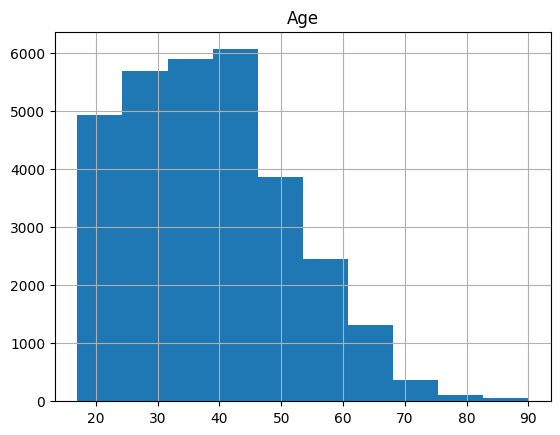

In [58]:
# See histogram of variable, possibly having outliers
outlier_var = 'Age'
num_df.hist(column=outlier_var)

<Axes: xlabel='Age'>

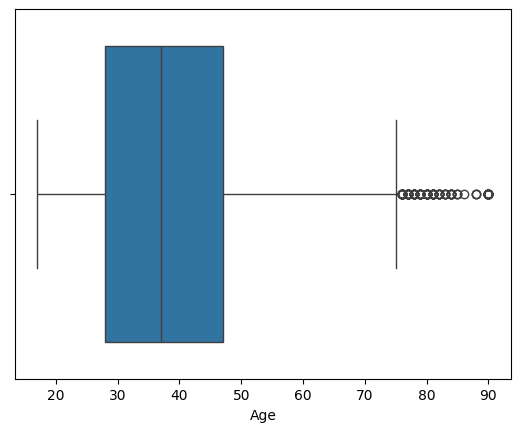

In [59]:
# See boxplot of variable, possibly having outliers
sns.boxplot(x=outlier_var, data=num_df)

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

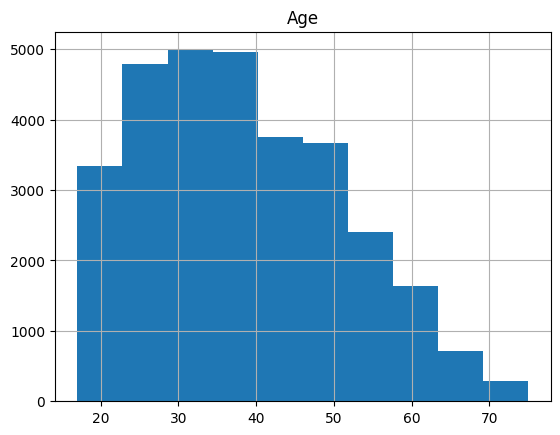

In [60]:
# Outliers removals by IQR-based threshold
q1 = num_df[outlier_var].quantile(0.25)
q3 = num_df[outlier_var].quantile(0.75)
iqr = q3-q1
temp_df = num_df[~((num_df[outlier_var] < q1-1.5*iqr) | (num_df[outlier_var] > q3+1.5*iqr))]
temp_df.hist(column=outlier_var)

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

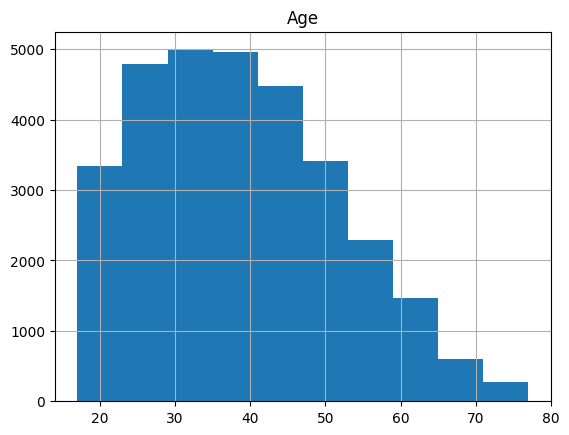

In [61]:
# Outliers removals by SD-based thresholds
mean = num_df[outlier_var].mean()
sd = num_df[outlier_var].std()
temp_df2 = num_df[~((num_df[outlier_var] < mean-3*sd) | (num_df[outlier_var] > mean+3*sd))]
temp_df2.hist(column=outlier_var)

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

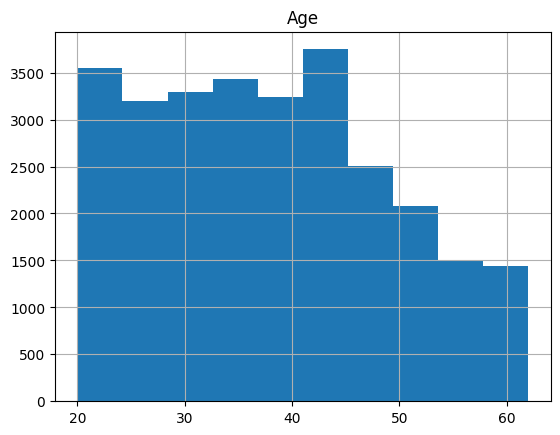

In [62]:
# Outliers removals by 5% and 95% percentiles
p05 = num_df[outlier_var].quantile(0.05)
p95 = num_df[outlier_var].quantile(0.95)
temp_df3 = num_df[~((num_df[outlier_var] < p05) | (num_df[outlier_var] > p95))]
temp_df3.hist(column=outlier_var)

In [63]:
# Check out the updated size after outlier removals
print(temp_df.shape)
print(temp_df2.shape)
print(temp_df3.shape)

(30546, 6)
(30596, 6)
(27975, 6)


## Numerical Data: Correlation

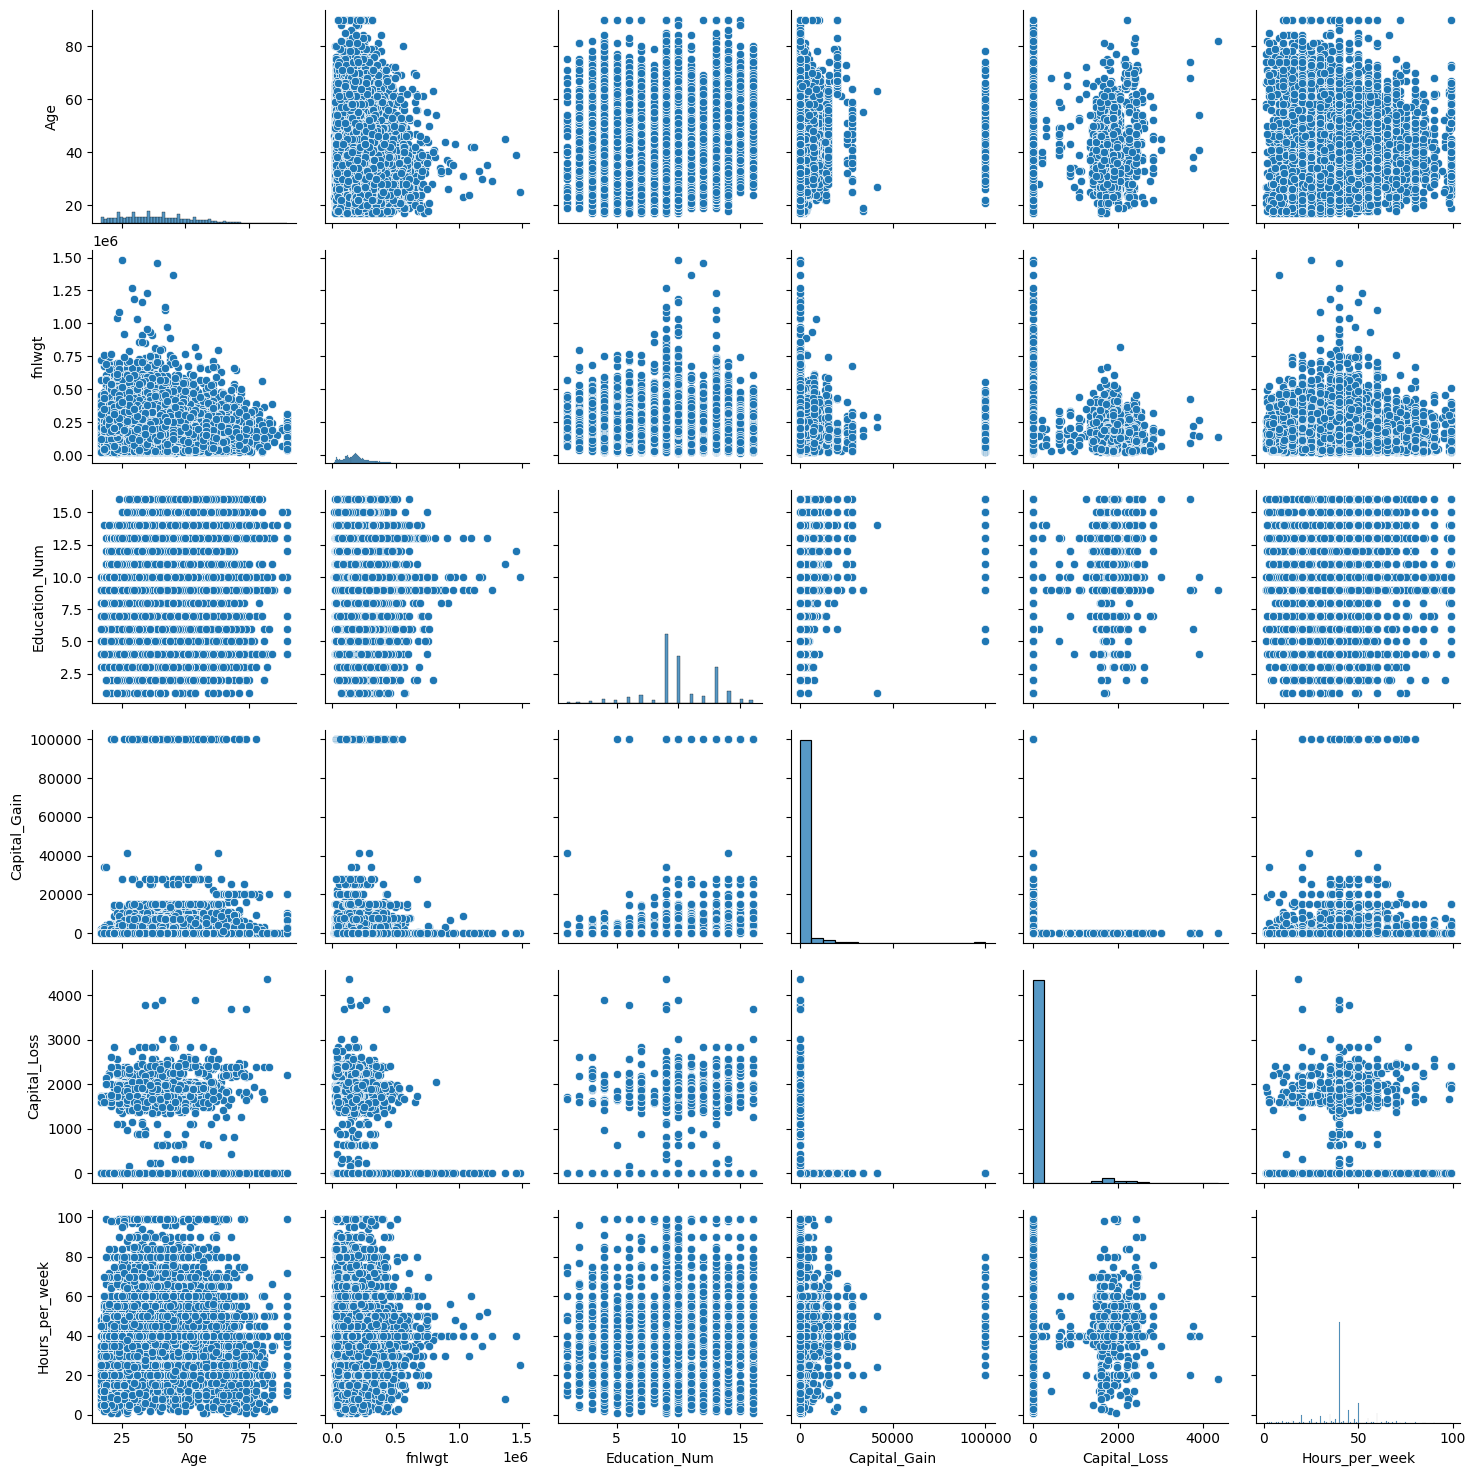

In [64]:
# Plot scatterplot matrix
sns.pairplot(num_df)
# See more option of pairplot at https://seaborn.pydata.org/generated/seaborn.pairplot.html

In [65]:
# Plot scatterplot matrix of sub-datasets
# hue_var = 'Age'
# sns.pairplot(num_df, hue=hue_var)

In [66]:
# Plot scatterplot matrix of specific variables
# Using hue with various value doesn't fit the pairplot well
# sns.pairplot(num_df, vars = ['fnlwgt', 'Capital_Gain', 'Capital_Loss'], hue=hue_var, markers=["o", "D"])

<Axes: >

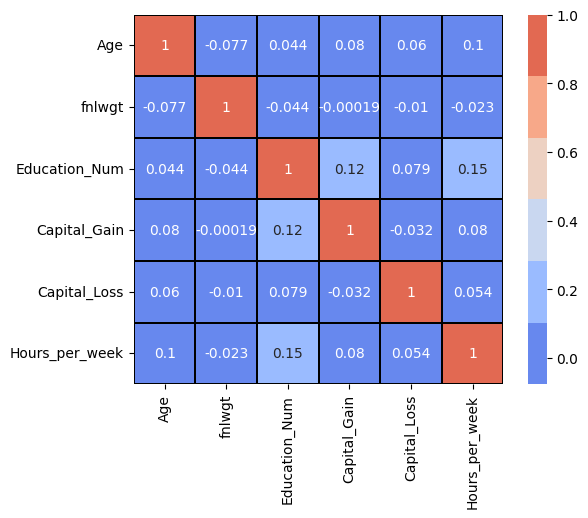

In [67]:
# Plot heatmap of correlation coefficients 
sns.heatmap(num_df.corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=True)

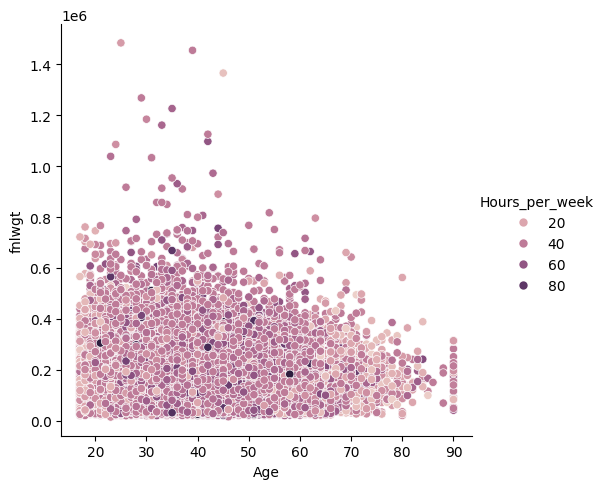

In [68]:
# Plot scatter plot of one variable pair 
hue_var = "Hours_per_week"
sns.relplot(data=num_df,
            x="Age", 
            y="fnlwgt",
            hue=hue_var)

In [69]:
# Plot bubble plot of four variables
# hue_var = "Survived"
# size_var = "Pclass"
# sns.relplot(data=num_df,
#             x="Age", 
#             y="Fare", 
#             hue=hue_var, 
#             size=size_var,
#             sizes=(20, 100), 
#             alpha=0.8,
#             palette=sns.color_palette("muted",len(num_df[hue_var].unique())))

### Nominal Data Analysis

In [70]:
# Construct frequencies of each value in selected_var
selected_var = 'Education_Num'
y = new_df[selected_var].value_counts()
x_arr = y.index.tolist()

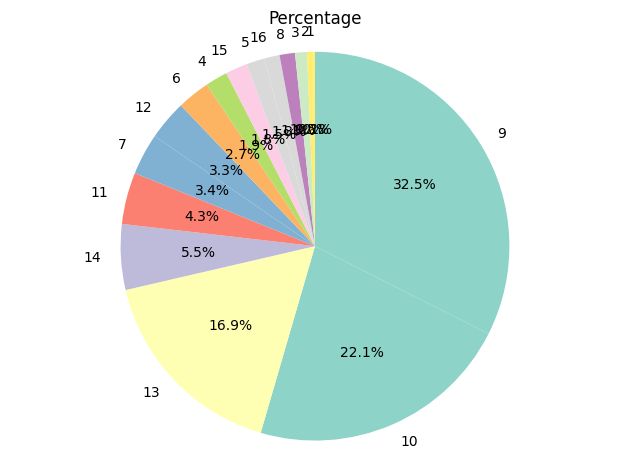

In [71]:
# Pie graph example 

cmap = plt.cm.Set3
colors = cmap(np.linspace(0, 1, len(x_arr)))

fig, ax = plt.subplots()
ax.pie(y, labels=x_arr, 
       colors=colors,
       startangle=90, 
       counterclock=False,
       autopct='%1.1f%%')
ax.axis('equal')
ax.set_title('Percentage')

plt.tight_layout()
plt.savefig('pie.jpg')

plt.show()
# See more about pie graph at https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html#matplotlib.pyplot.pie

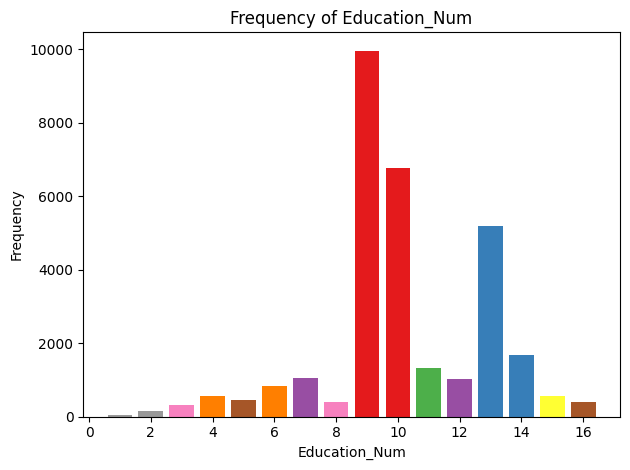

In [72]:
# Bar graph example
selected_var = 'Education_Num'
y = new_df[selected_var].value_counts()
x_arr = y.index.tolist()

cmap = plt.cm.Set1
colors = cmap(np.linspace(0, 1, len(x_arr)))

fig, ax = plt.subplots()
ax.bar(x_arr, y, color=colors)

ax.set_xlabel(selected_var)
ax.set_ylabel('Frequency')
ax.set_title('Frequency of ' + selected_var)

plt.tight_layout()
plt.savefig('bar.jpg')

plt.show()
# See more about bar graph at https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

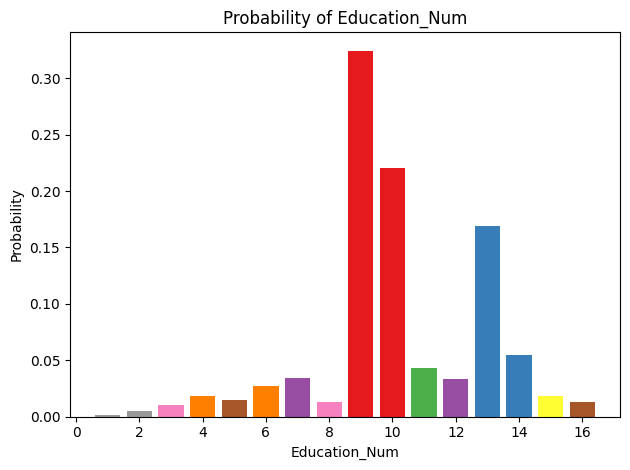

In [73]:
# Find probablity of passengers

selected_var = 'Education_Num'
y = new_df[selected_var].value_counts(normalize=True)
x_arr = y.index.tolist()

cmap = plt.cm.Set1
colors = cmap(np.linspace(0, 1, len(x_arr)))

fig, ax = plt.subplots()
ax.bar(x_arr, y, color=colors)

ax.set_xlabel(selected_var)
ax.set_ylabel('Probability')
ax.set_title('Probability of ' + selected_var)

plt.tight_layout()
plt.savefig('prob_bar.jpg')

plt.show()
# See more about bar graph at https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

In [74]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Compute Cramér’s V for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

print(cramers_v(df['Workclass'], df['Education_Num']))

print(cramers_v(df['Education_Num'], df['Workclass']))

0.09936889764801388
0.09936889764801388


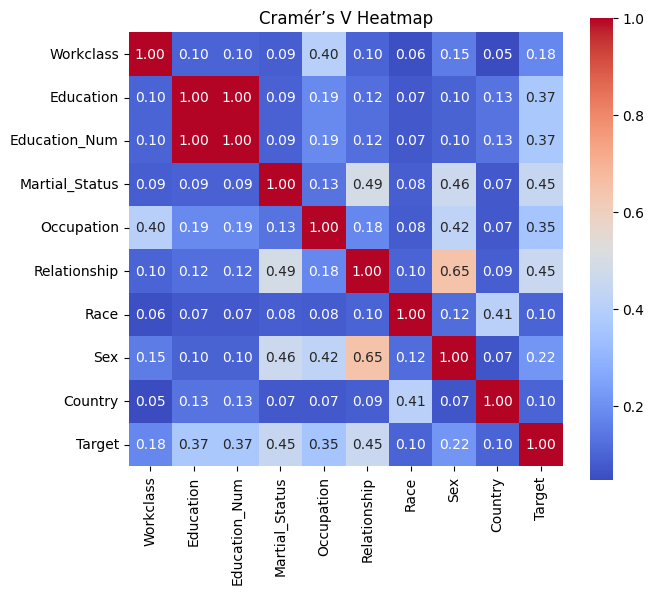

In [75]:
def cramer_matrix(df):
    """Compute pairwise Cramér’s V (symmetric)"""
    cols = df.columns
    
    cramer_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
    
    for c1 in cols:
        for c2 in cols:
            cramer_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])
    
    return cramer_matrix

cat_vars = ['Workclass', 'Education', 'Education_Num',
       'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
       'Country', 'Target']
cat_df = df[cat_vars]
cramer_matrix = cramer_matrix(cat_df)

plt.figure(figsize=(7,6))
sns.heatmap(cramer_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Cramér’s V Heatmap")
plt.show()

In [76]:
def conditional_entropy(x, y):
    """Compute H(X|Y)."""
    # Joint distribution P(x, y)
    xy = pd.crosstab(x, y, normalize="all")

    # Marginal distribution P(y)
    py = xy.sum(axis=0)

    # Conditional distribution P(x|y)
    p_x_given_y = xy.div(py, axis=1)

    # H(X|Y) = sum_y P(y) * H(X|Y=y)
    entropy = -np.nansum(py * (p_x_given_y * np.log2(p_x_given_y)).sum(axis=0))
    return entropy


def entropy(x):
    """Compute H(X)."""
    p = x.value_counts(normalize=True)
    return -np.sum(p * np.log2(p))


def theils_u(x, y):
    """
    Compute Theil’s U (Uncertainty Coefficient) U(X|Y):
    How much knowing Y reduces the uncertainty of X.
    """
    h_x = entropy(x)
    h_x_given_y = conditional_entropy(x, y)

    if h_x == 0:
        return 1.0  # X has no uncertainty at all

    return (h_x - h_x_given_y) / h_x

print(theils_u(df['Education'],df['Education_Num']))  # How much does knowing 'Survived' help me predict 'Pclass'?

print(theils_u(df['Education_Num'],df['Education']))   # How much does knowing 'Pclass' help me predict 'Survived'?

1.0
1.0


/home/hamtako/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/home/hamtako/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


/home/hamtako/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/home/hamtako/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/home/hamtako/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/home/hamtako/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/home/hamtako/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)
/home/hamtako/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by ze

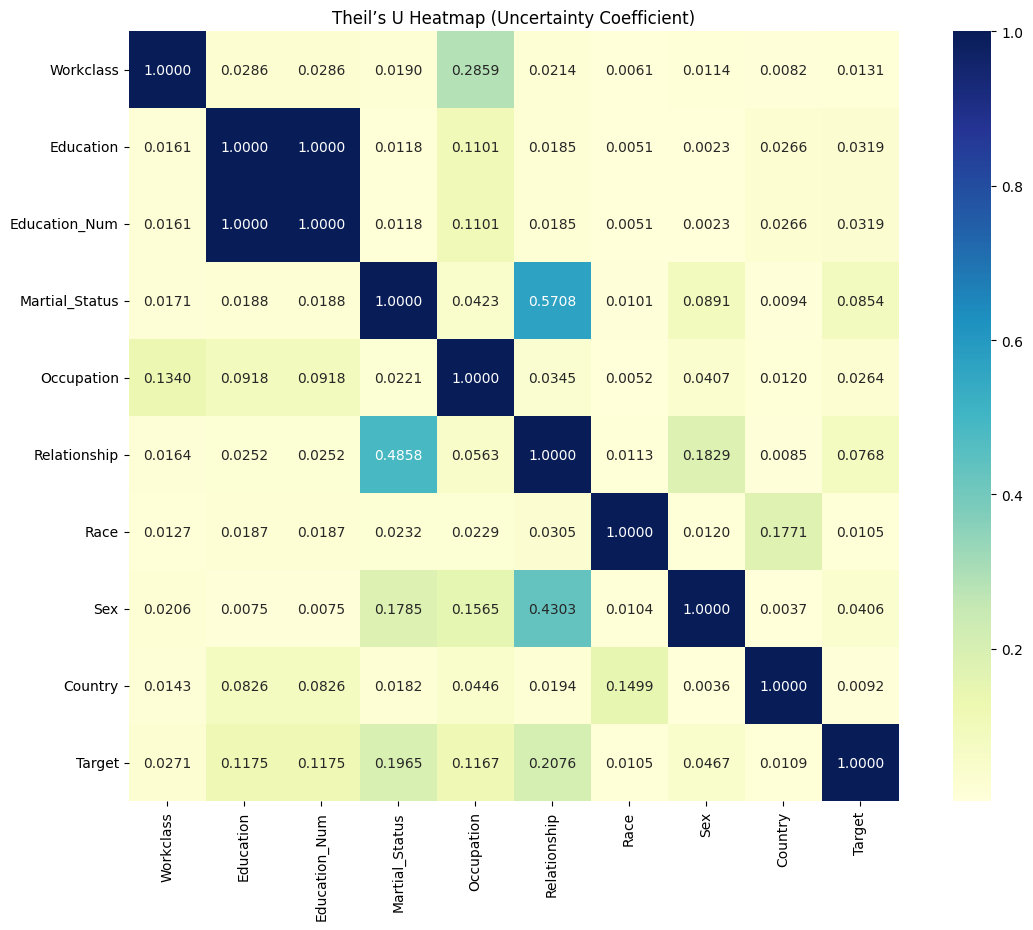

In [77]:
def theils_u_matrix(df):
    cols = df.columns
    matrix = pd.DataFrame(index=cols, columns=cols)
    
    for c1 in cols:
        for c2 in cols:
            matrix.loc[c1, c2] = theils_u(df[c1], df[c2])
    
    return matrix.astype(float)

cat_vars = ['Workclass', 'Education', 'Education_Num',
       'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
       'Country', 'Target']
cat_df = df[cat_vars]
u_matrix = theils_u_matrix(cat_df)
#u_matrix_sorted = u_matrix.sort_values(by=u_matrix.index.tolist(), axis=1)

# Plot heatmap
plt.figure(figsize=(14,10))
#sns.heatmap(u_matrix_sorted, annot=True, cmap="YlGnBu")
sns.heatmap(u_matrix, annot=True, cmap="YlGnBu", fmt=".4f", square=True)
plt.title("Theil’s U Heatmap (Uncertainty Coefficient)")
plt.show()

## Nominal vs. Numerical Data Analysis

In [78]:
# Compute basic statistic of sub-datasets
num_df.groupby('Education_Num').Age.mean()

Education_Num
1     41.456522
2     44.782051
3     41.788779
4     47.527051
5     40.384449
6     37.892900
7     32.367424
8     32.104326
9     38.628712
10    36.107159
11    38.233157
12    37.215686
13    38.653223
14    43.771343
15    44.139785
16    47.103015
Name: Age, dtype: float64

<Axes: xlabel='Race', ylabel='Age'>

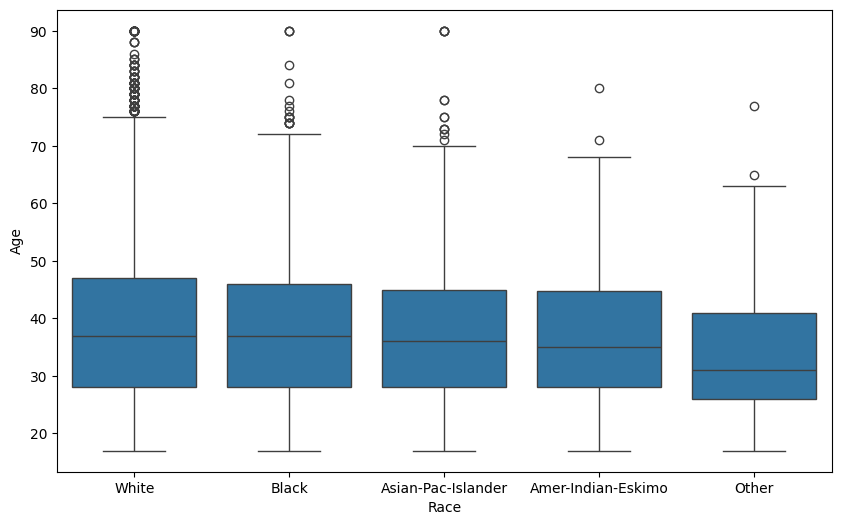

In [79]:
# Plot boxplots of 2 data subsets, splitted by 'Survived'
x_var = 'Race'
plt.figure(figsize=(10, 6))
sns.boxplot(x=x_var, y='Age', data=new_df)

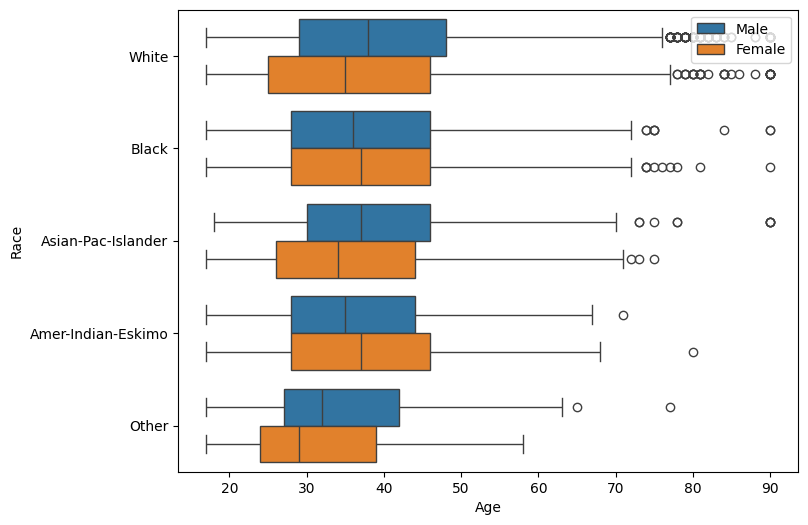

In [80]:
# Plot boxplots of data, splitted by 'Survived' AND 'Passenger Class'
fig = plt.figure(figsize = (8,6))
hue_var = 'Sex'
sns.boxplot(x='Age',y='Race', data=new_df, hue='Sex')
plt.legend(loc='upper right')

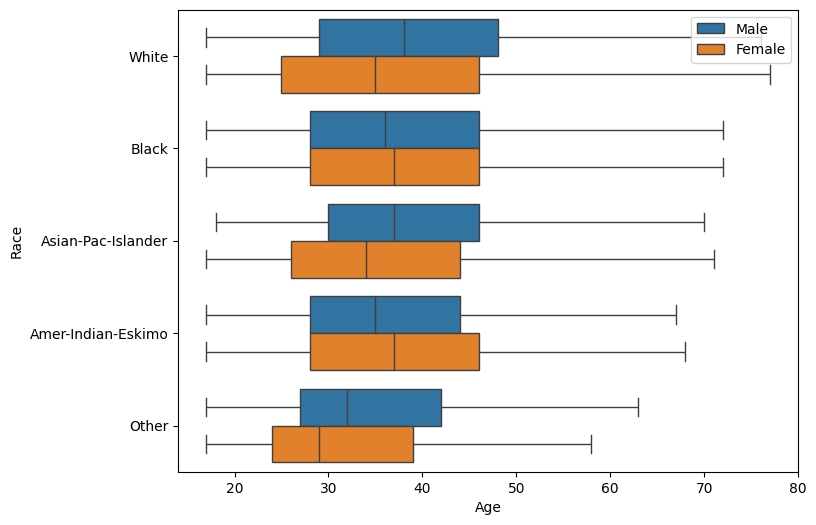

In [81]:
# Plot boxplots of data, splitted by 'Survived' AND 'Passenger Class'
# Plot without outliers

fig = plt.figure(figsize = (8,6))
sns.boxplot(x='Age', y='Race', data=new_df, hue='Sex', showfliers=False)
plt.legend(loc='upper right')